# Smart Workspace Monitor — Experiments
Phase 3 & 4 notebook: EDA → model training → evaluation → visualisations

In [9]:
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import tensorflow as tf
import joblib

# Paths
BASE  = os.path.abspath(os.path.join(os.getcwd(), '..'))
CSV   = os.path.join(BASE, 'dataset', 'processed', 'images.csv')
MDIR  = os.path.join(BASE, 'models', 'context_classifier')
RDIR  = os.path.join(BASE, 'results', 'metrics')

plt.style.use('seaborn-v0_8-whitegrid')
print('TF:', tf.__version__)

TF: 2.21.0


## 1  Exploratory Data Analysis

In [10]:
df = pd.read_csv("C:\\Users\\Laptop\\Desktop\\context-aware-object-detection\\src\\dataset\\processed\\synthetic_dataset.csv")
# Normalise label column to 0/1
if df['label'].dtype == object:
    df['label'] = df['label'].map({'Focused':1,'Distracted':0,'focused':1,'distracted':0})
print(df.shape)
df.head()

(200, 16)


,total_objects,productive_count,distracting_count,neutral_count,productive_ratio,distracting_ratio,focused_score,avg_object_area,total_area_coverage,avg_confidence,clutter_score,has_laptop,has_phone,has_book,has_person,label
0,4,2,0,2,0.811876,0.179055,0.467500,0.059997,0.237775,0.700113,0.128573,1,0,1,1,1
1,3,2,0,1,0.709903,0.129584,0.374737,0.111185,0.141848,0.687643,0.173272,1,1,0,1,1
2,5,2,0,0,0.743018,0.051157,0.239031,0.144889,0.389690,0.842519,0.160923,0,0,1,0,1
3,2,4,0,1,0.656424,0.054671,0.653217,0.092516,0.162382,0.770310,0.106263,1,0,1,1,1
4,4,4,1,1,0.578393,0.013568,0.395198,0.088868,0.181405,0.848621,0.171351,1,0,0,1,1


In [11]:
print(df.describe().T.to_string())
print('\nClass distribution:')
print(df['label'].value_counts().rename({1:'Focused',0:'Distracted'}))

                     count      mean       std       min       25%       50%       75%       max
total_objects        200.0  4.335000  1.368260  2.000000  3.000000  4.000000  5.000000  7.000000
productive_count     200.0  1.630000  1.436460  0.000000  0.000000  1.500000  3.000000  4.000000
distracting_count    200.0  1.680000  1.377347  0.000000  0.000000  1.500000  3.000000  4.000000
neutral_count        200.0  1.370000  0.947411  0.000000  1.000000  1.000000  2.000000  3.000000
productive_ratio     200.0  0.441244  0.290092  0.003066  0.177501  0.447833  0.698170  0.898750
distracting_ratio    200.0  0.375745  0.254474  0.001390  0.144074  0.357638  0.599258  0.799765
focused_score        200.0 -0.001056  0.493719 -0.799134 -0.476282  0.048536  0.442916  0.791172
avg_object_area      200.0  0.116650  0.038359  0.050103  0.090143  0.111210  0.145665  0.198991
total_area_coverage  200.0  0.388357  0.165602  0.109391  0.264706  0.358464  0.524889  0.698192
avg_confidence       200.0  0.

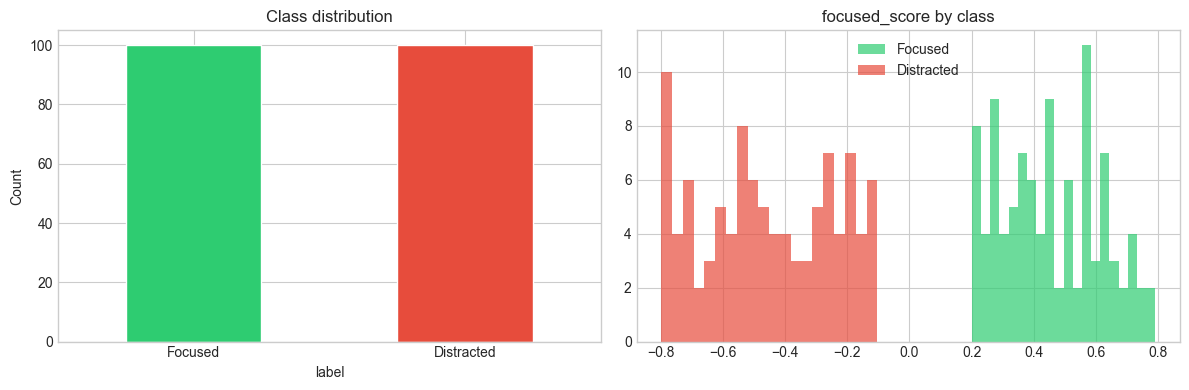

In [12]:
# Class distribution bar
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts = df['label'].value_counts().rename({1:'Focused', 0:'Distracted'})
counts.plot(kind='bar', color=['#2ecc71','#e74c3c'], ax=axes[0], edgecolor='white')
axes[0].set_title('Class distribution')
axes[0].set_xticklabels(counts.index, rotation=0)
axes[0].set_ylabel('Count')

# Focused vs Distracted: focused_score distribution
df[df.label==1]['focused_score'].hist(bins=20, alpha=0.7, label='Focused',
                                       color='#2ecc71', ax=axes[1])
df[df.label==0]['focused_score'].hist(bins=20, alpha=0.7, label='Distracted',
                                       color='#e74c3c', ax=axes[1])
axes[1].set_title('focused_score by class')
axes[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(RDIR, 'eda_class_distribution.png'), dpi=120)
plt.show()

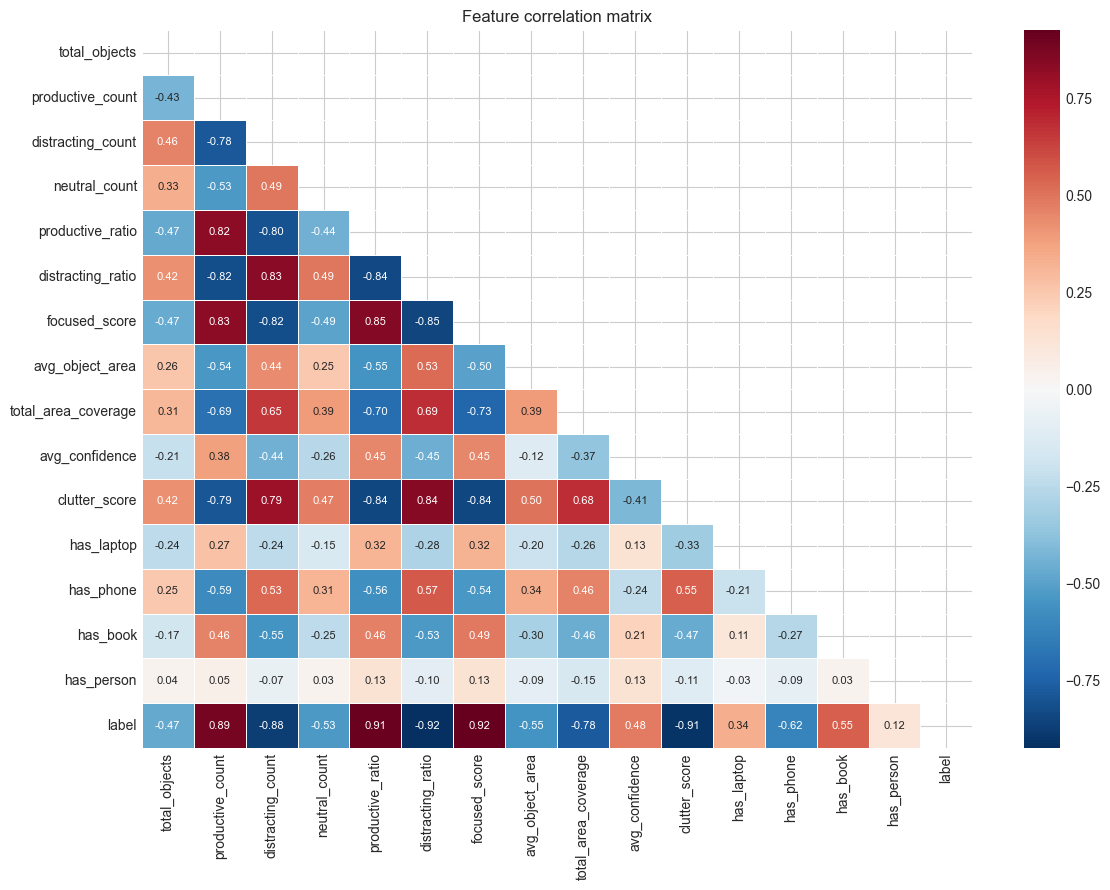

In [13]:
# Correlation heatmap
feat_cols = [c for c in df.columns if c != 'label']
plt.figure(figsize=(12, 9))
corr = df[feat_cols + ['label']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0,
            annot=True, fmt='.2f', linewidths=0.4, annot_kws={'size':8})
plt.title('Feature correlation matrix')
plt.tight_layout()
plt.savefig(os.path.join(RDIR, 'eda_correlation.png'), dpi=120)
plt.show()

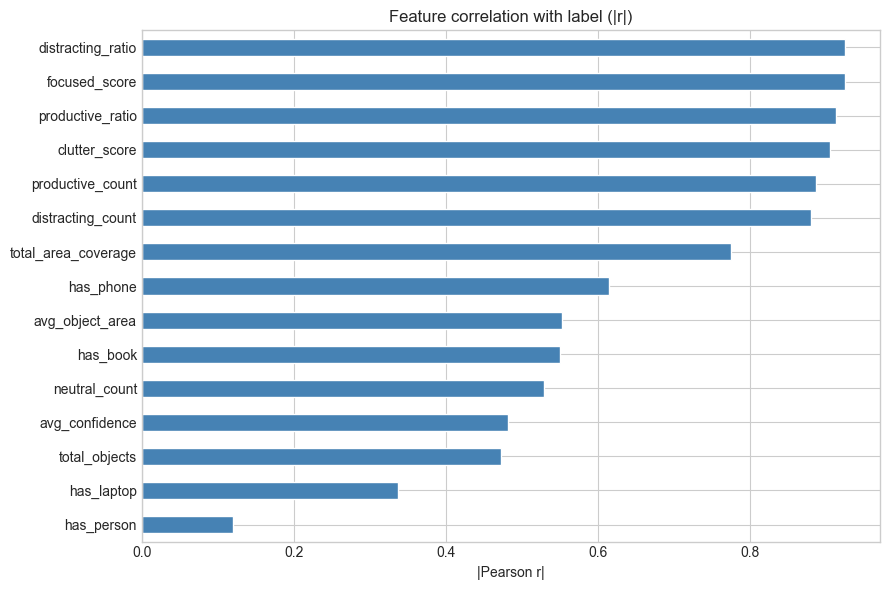

In [14]:
# Feature importance via correlation with label
corr_label = df[feat_cols].corrwith(df['label']).abs().sort_values(ascending=True)
corr_label.plot(kind='barh', figsize=(9, 6), color='steelblue', edgecolor='white')
plt.title('Feature correlation with label (|r|)')
plt.xlabel('|Pearson r|')
plt.tight_layout()
plt.savefig(os.path.join(RDIR, 'eda_feature_importance.png'), dpi=120)
plt.show()

## 2  Train / Evaluate Model
> Run `python src/train_context_model.py` first, then load the saved model below.

In [15]:
model   = tf.keras.models.load_model(os.path.join(MDIR, 'context_model.keras'))
scaler  = joblib.load(os.path.join(MDIR, 'scaler.pkl'))
with open(os.path.join(MDIR, 'feature_cols.json')) as f:
    feature_cols = json.load(f)

X = df[feature_cols].values.astype(np.float32)
y = df['label'].values.astype(np.int32)

_, X_test, _, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
X_test_sc = scaler.transform(X_test)

y_prob = model.predict(X_test_sc, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print(classification_report(y_test, y_pred, target_names=['Distracted','Focused']))

              precision    recall  f1-score   support

  Distracted       1.00      1.00      1.00        15
     Focused       1.00      1.00      1.00        15

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



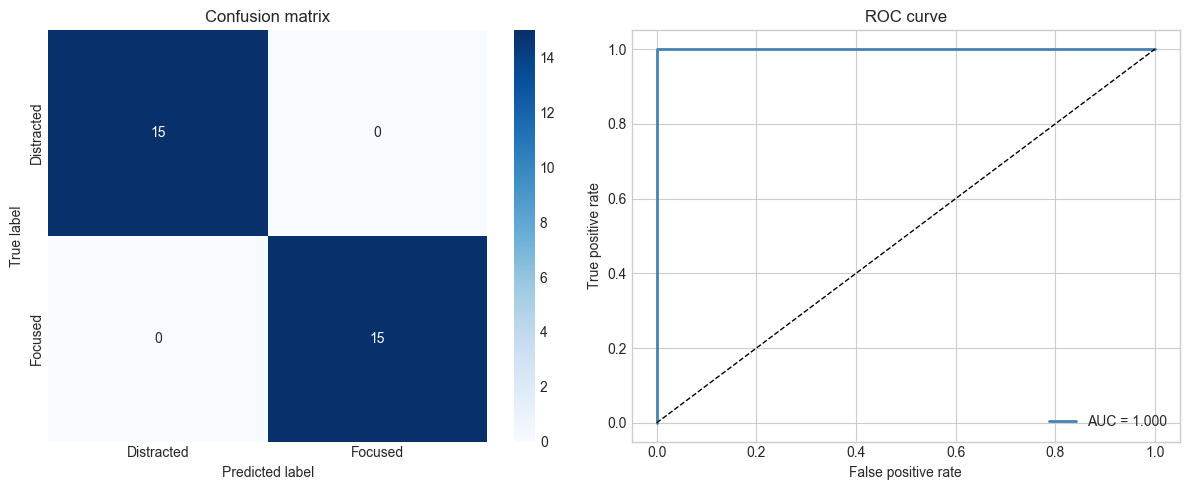

In [16]:
# Confusion matrix + ROC side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Distracted','Focused'],
            yticklabels=['Distracted','Focused'], ax=axes[0])
axes[0].set_ylabel('True label')
axes[0].set_xlabel('Predicted label')
axes[0].set_title('Confusion matrix')

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0,1],[0,1],'k--',lw=1)
axes[1].set_xlabel('False positive rate')
axes[1].set_ylabel('True positive rate')
axes[1].set_title('ROC curve')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(RDIR, 'eval_cm_roc.png'), dpi=120)
plt.show()

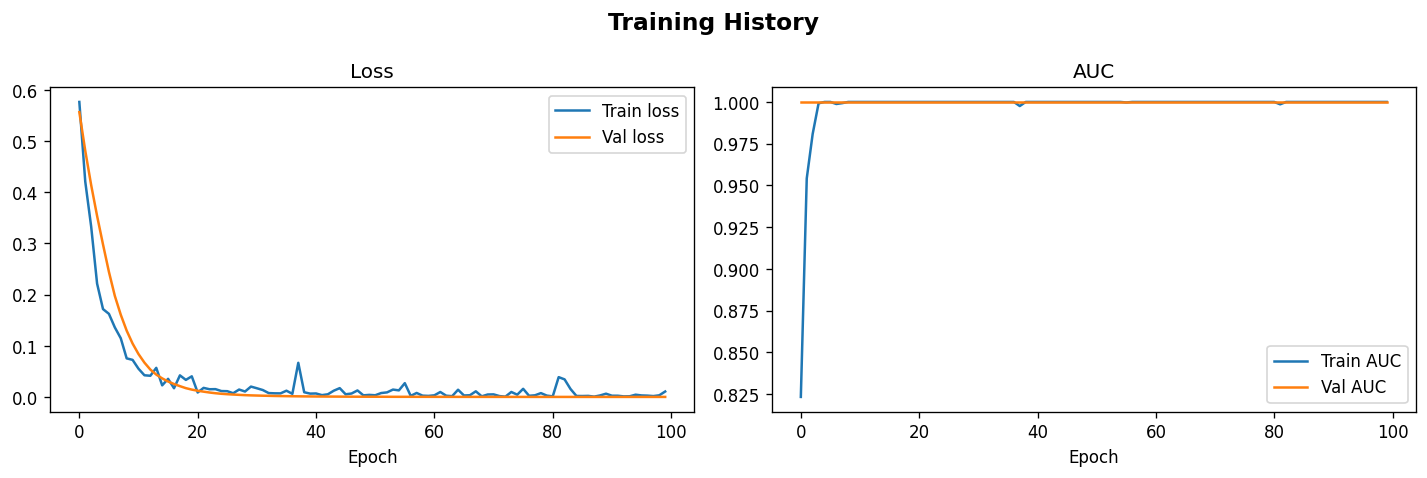

In [17]:
# Load and plot training history
history_img = os.path.join(RDIR, 'training_history.png')
if os.path.exists(history_img):
    from IPython.display import Image
    display(Image(history_img))
else:
    print('Run train_context_model.py to generate training_history.png')

## 3  Metrics Summary

In [18]:
metrics_path = os.path.join(RDIR, 'metrics.json')
if os.path.exists(metrics_path):
    with open(metrics_path) as f:
        m = json.load(f)
    print('Test accuracy:', f"{m['test_accuracy']:.4f}")
    print('Test AUC:     ', f"{m['test_auc']:.4f}")
    print('N test:       ', m['n_test'])
else:
    print('metrics.json not found — run train_context_model.py')

Test accuracy: 1.0000
Test AUC:      1.0000
N test:        30
